In [1]:
import torch
import torch.nn as nn
from networks import FullyConnectedNN, NoisyFullyConnectedNN, FixNoiseFullyConnectedNN, DropoutFullyConnectedNN
import os
import pandas as pd
import numpy as np
from utils import *
import shutil
import re

用的是cv fold0的model，数据还是test data

In [9]:
dataset_name = 'bostonHousing'
batch_size = 32
optimizer_name = "Adam"
model_names = ['FCN', 'noisyFCN', 'fixnoiseFCN', 'dropoutFCN']
learning_rate = 0.005
weight_decay = 0.0
epochs = 50

In [11]:
result_df = pd.read_csv("settings_loss.csv", index_col=0)
result_df

,dataset_name,model_name,batch_size,weight_decay,learning_rate,epoch2loss,best_epoch,best_loss,fix_noiselevel,init_noiselevel,dropout_prob
0,bostonHousing,FCN,32,0.10000,0.001,"0:0.6341015617420644,10:0.23431518995835457,20...",130,0.207891,0.01,0.010,0.01
1,bostonHousing,FCN,32,0.01000,0.001,"0:0.5677161419097289,10:0.1969293736749225,20:...",100,0.164547,0.01,0.010,0.01
2,energy,FCN,32,0.10000,0.001,"0:0.30231431666118663,10:0.0870186047472867,20...",20,0.086956,0.01,0.010,0.01
3,bostonHousing,FCN,32,0.00100,0.001,"0:0.5252858572168114,10:0.1819583551751243,20:...",80,0.150847,0.01,0.010,0.01
4,bostonHousing,FCN,32,0.00010,0.001,"0:0.5802548202099623,10:0.1909585953126719,20:...",90,0.143937,0.01,0.010,0.01
...,...,...,...,...,...,...,...,...,...,...,...
4389,wine-quality-red,noisyFCN,32,0.01000,0.002,"0:0.6357030493722242,10:0.615885292668553,20:0...",10,0.615885,0.01,0.005,0.01
4390,yacht,noisyFCN,32,0.00010,0.002,"0:0.6014675604445594,10:0.09661235119189535,20...",80,0.056779,0.01,0.005,0.01
4391,yacht,noisyFCN,32,0.01000,0.002,"0:0.5558578363851625,10:0.09015239092160243,20...",160,0.043652,0.01,0.001,0.01
4392,yacht,noisyFCN,32,0.00001,0.002,"0:0.5339653475576518,10:0.08310938859776575,20...",60,0.045593,0.01,0.005,0.01


In [16]:
result_df = result_df[result_df['batch_size']==32]

In [19]:
result_df.loc[result_df.groupby(['dataset_name', 'model_name'])['best_loss'].idxmin()]

,dataset_name,model_name,batch_size,weight_decay,learning_rate,epoch2loss,best_epoch,best_loss,fix_noiselevel,init_noiselevel,dropout_prob
295,bostonHousing,FCN,32,1.000000e-09,0.0020,"0:0.42754516290661726,10:0.16623258088473922,2...",50,0.130827,0.010,0.010,0.010
788,bostonHousing,dropoutFCN,32,1.000000e-05,0.0020,"0:0.4545082779762186,10:0.18016028223950187,20...",140,0.123964,0.010,0.010,0.100
889,bostonHousing,fixnoiseFCN,32,1.000000e-04,0.0020,"0:0.42114480491037726,10:0.16427625270537388,2...",50,0.137724,0.100,0.010,0.010
984,bostonHousing,noisyFCN,32,1.000000e-03,0.0020,"0:0.42697348813583824,10:0.17045451636299674,2...",110,0.129769,0.010,0.001,0.010
1625,concrete,FCN,32,1.000000e-03,0.0001,"0:0.932977069548475,10:0.47344995766063125,20:...",950,0.099598,0.010,0.010,0.010
2357,concrete,dropoutFCN,32,1.000000e-03,0.0020,"0:0.41101030909874137,10:0.1586751767206615,20...",230,0.091614,0.100,0.010,0.100
2178,concrete,fixnoiseFCN,32,1.000000e-04,0.0010,"0:0.5148124917674224,10:0.16869788727228147,20...",160,0.100055,0.100,0.010,0.010
2224,concrete,noisyFCN,32,1.000000e-03,0.0001,"0:0.9504759899598973,10:0.4741835464077885,20:...",790,0.098690,0.010,0.005,0.010
2572,energy,FCN,32,1.000000e-03,0.0001,"0:0.8502539616226594,10:0.16573131187397785,20...",1100,0.010171,0.010,0.010,0.010
2904,energy,dropoutFCN,32,1.000000e-05,0.0020,"0:0.14657467055400974,10:0.06154995248571691,2...",110,0.009046,0.100,0.010,0.010


In [ ]:
for model_name in model_names:
    if model_name == 

In [3]:
X_train, y_train, X_test, y_test = load_uci_data_test(dataset_name)
eval_path = os.path.join(os.getcwd(), 'evaluations')
# Create eval dir for dataset
dataset_path = os.path.join(eval_path, dataset_name)
if dataset_name == 'protein-tertiary-structure':
    hidden_sizes = [100, 100]
else:
    hidden_sizes = [50, 50]
use_cuda = torch.cuda.is_available()

# Get dataset configuration
feature_indices, target_indices = load_uci_info(dataset_name)
input_size = len(feature_indices)
output_size = len(target_indices)
print(input_size, output_size)
print(len(X_train), len(X_test), len(X_train)+len(X_test))

13 1
405 101 506


/home/xueqiong/noise_injection_uncertainty/regression/utils.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(dataset_path, engine='python', header=None, delim_whitespace=True)


In [4]:
def def_model(model_name, input_size, hidden_sizes, output_size):
    print('model_name', model_name)
    if model_name == 'FCN':
        net = FullyConnectedNN(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size)
    elif model_name == 'noisyFCN':
        net = NoisyFullyConnectedNN(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size, init_noiselevel=init_noiselevel)
    elif model_name == 'fixnoiseFCN':
        net = FixNoiseFullyConnectedNN(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size, fix_noiselevel=fix_noiselevel)
    elif model_name == 'dropoutFCN':
        net = DropoutFullyConnectedNN(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size, dropout_prob=dropout_prob)
    return net

def validate(model, val_loader, criterion, test_times=100):
    model.eval()
    if 'Dropout' in model._get_name():
        recursive_module_iteration(model)
    losses = AverageMeter()
    with torch.no_grad():
        var_outputs_all = []
        pred_all = []
        for inputs, labels in val_loader:
            outputs = torch.zeros((inputs.shape[0], 1, test_times))
            if use_cuda:
                labels = labels.cuda()
                inputs = inputs.cuda()
                outputs = outputs.cuda()
            # compute output
            for i in range(test_times):
                output = model(inputs)
                outputs[:, :, i] = output
            avg_outputs = torch.mean(outputs, dim=2)
            var_outputs = torch.sum(torch.var(outputs, dim=2), dim=-1)
            loss = criterion(avg_outputs, labels)
            losses.update(loss.item(), inputs.size(0))
            if use_cuda:
                var_outputs = var_outputs.cpu()
                avg_outputs = avg_outputs.cpu()
            var_outputs = var_outputs.numpy().tolist()
            var_outputs_all.extend(var_outputs)
            avg_outputs = avg_outputs.numpy().tolist()
            pred_all.extend(avg_outputs)
            
    return losses.avg, var_outputs_all, pred_all

def recursive_module_iteration(module, depth=0):
    # 打印当前模块的信息
    print(f"{' ' * (depth * 2)}Module: {module.__class__.__name__}")

    # 如果当前模块是容器模块（如 Sequential），则递归遍历其子模块
    if hasattr(module, "children"):
        for child in module.children():
            recursive_module_iteration(child, depth + 1)
    if isinstance(module, nn.Dropout):
        module.train()
        print('dropout设置为训练模式')

def get_first_path():
    global model_name, fix_noiselevel, init_noiselevel, dropout_prob, dataset_path, batch_size, learning_rate, optimizer_name, fold
    if model_name == 'fixnoiseFCN':
        model_name2 = model_name + '_{}'.format(fix_noiselevel)
    elif model_name == 'noisyFCN':
        model_name2 = model_name + '_{}'.format(init_noiselevel)
    elif model_name == 'dropoutFCN':
        model_name2 = model_name + '_{}'.format(dropout_prob)
    else:
        model_name2 = model_name
    save_path = os.path.join(dataset_path, 'save_model_cv', model_name2+'_bs_{}_lr_{}_wd{}_optm_{}'.format(batch_size, learning_rate, weight_decay, optimizer_name), 'fold_{}'.format(fold))
    first_path = os.path.join(save_path, [path for path in os.listdir(save_path) if '.' not in path][0])
    return save_path, first_path

In [5]:
folders = os.listdir(os.path.join(dataset_path, 'save_model_cv'))
print(folders)

['noisyFCN_0.2_bs_32_lr_0.005_wd0.0_optm_Adam', 'noisyFCN_0.01_bs_32_lr_0.005_wd0.0_optm_Adam', 'fixnoiseFCN_0.2_bs_32_lr_0.005_wd0.0_optm_Adam', 'FCN_bs_32_lr_0.005_wd0.0_optm_Adam', 'fixnoiseFCN_0.01_bs_32_lr_0.005_wd0.0_optm_Adam', 'fixnoiseFCN_0.1_bs_32_lr_0.005_wd0.0_optm_Adam', 'fixnoiseFCN_0.05_bs_32_lr_0.005_wd0.0_optm_Adam', 'noisyFCN_0.05_bs_32_lr_0.005_wd0.0_optm_Adam', 'dropoutFCN_0.005_bs_32_lr_0.005_wd0.0_optm_Adam', 'noisyFCN_0.1_bs_32_lr_0.005_wd0.0_optm_Adam', 'dropoutFCN_0.05_bs_32_lr_0.005_wd0.0_optm_Adam']


In [6]:
if dataset_name == 'protein-tertiary-structure':
    folders = [folder for folder in folders if optimizer_name in folder]
print(folders)

['noisyFCN_0.2_bs_32_lr_0.005_wd0.0_optm_Adam', 'noisyFCN_0.01_bs_32_lr_0.005_wd0.0_optm_Adam', 'fixnoiseFCN_0.2_bs_32_lr_0.005_wd0.0_optm_Adam', 'FCN_bs_32_lr_0.005_wd0.0_optm_Adam', 'fixnoiseFCN_0.01_bs_32_lr_0.005_wd0.0_optm_Adam', 'fixnoiseFCN_0.1_bs_32_lr_0.005_wd0.0_optm_Adam', 'fixnoiseFCN_0.05_bs_32_lr_0.005_wd0.0_optm_Adam', 'noisyFCN_0.05_bs_32_lr_0.005_wd0.0_optm_Adam', 'dropoutFCN_0.005_bs_32_lr_0.005_wd0.0_optm_Adam', 'noisyFCN_0.1_bs_32_lr_0.005_wd0.0_optm_Adam', 'dropoutFCN_0.05_bs_32_lr_0.005_wd0.0_optm_Adam']


In [7]:
# folders = ['fixnoiseFCN_0.1_bs_128_lr_0.005_wd0.0_optm_RMSprop']
folders = [folder for folder in folders if 'dropout' in folder]
for folder in folders:
    if folder[:3] == 'FCN':
        continue
    if 'noisyFCN' in folder:
        model_name = 'noisyFCN'
        init_noiselevel = float(re.search(r'noisyFCN_(.*?)_', folder).group(1))
    elif 'dropoutFCN' in folder:
        model_name = 'dropoutFCN'
        dropout_prob = float(re.search(r'dropoutFCN_(.*?)_', folder).group(1))
    elif 'fixnoiseFCN' in folder:
        model_name = 'fixnoiseFCN'
        fix_noiselevel = float(re.search(r'fixnoiseFCN_(.*?)_', folder).group(1))
    else:
        model_name = 'FCN'

    # 直接选第一个fold看结果
    fold = 0
    print('fold {}'.format(fold))
    X_train, y_train, X_val, y_val = load_uci_data_test(dataset_name)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32)
    val_data = torch.utils.data.TensorDataset(X_val, y_val)
    val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4)
    last_model = def_model(model_name, input_size, hidden_sizes, output_size)
    best_model = def_model(model_name, input_size, hidden_sizes, output_size)
    criterion = nn.MSELoss()
    if use_cuda:
        last_model.cuda()
        best_model.cuda()
        criterion.cuda()

    save_path, first_path = get_first_path()
    print('first_path: {}'.format(first_path))

    # 只选第一个模型
    last_model_path = os.path.join(first_path, 'checkpoint.pth.tar')
    best_model_path = os.path.join(first_path, 'model_best.pth.tar')
    last_checkpoint = torch.load(last_model_path)
    best_checkpoint = torch.load(best_model_path)

    state_tmp1 = last_model.state_dict()
    if 'state_dict' in last_checkpoint.keys():
        state_tmp1.update(last_checkpoint['state_dict'])
    else:
        state_tmp1.update(last_checkpoint)

    last_model.load_state_dict(state_tmp1)
    print("=> loaded last_model '{}' (epoch {})".format(last_model_path, last_checkpoint['epoch']))

    state_tmp2 = best_model.state_dict()
    if 'state_dict' in best_checkpoint.keys():
        state_tmp2.update(best_checkpoint['state_dict'])
    else:
        state_tmp2.update(best_checkpoint)

    best_model.load_state_dict(state_tmp2)
    print("=> loaded best_model '{}' (epoch {})".format(best_model_path, best_checkpoint['epoch']))

    val_loss_last, var_outputs_all_last, pred_all_last = validate(model=last_model, val_loader=val_loader, criterion=criterion)
    val_loss_best, var_outputs_all_best, pred_all_best = validate(model=best_model, val_loader=val_loader, criterion=criterion)
    print(var_outputs_all_last)
    sorted_index_last = np.argsort(var_outputs_all_last)
    sorted_index_best = np.argsort(var_outputs_all_best)
    total_num = len(sorted_index_last)
    y_pre_array_last = np.array(pred_all_last)
    y_pre_array_best = np.array(pred_all_best)
    y_test = np.array(val_data.tensors[1])
    sorted_y_pred_last = y_pre_array_last[sorted_index_last]  # 从预测方差从小到大排序
    sorted_y_pred_best = y_pre_array_best[sorted_index_best]  # 从预测方差从小到大排序
    sorted_y_data_last = y_test[sorted_index_last]
    sorted_y_data_best = y_test[sorted_index_best]
    loss_list_last = []
    loss_list_best = []

    for i in range(1, total_num + 1):
        sorted_y_pred1_last = sorted_y_pred_last[0:i]
        sorted_y_pred1_best = sorted_y_pred_best[0:i]
        sorted_y_data1_last = sorted_y_data_last[0:i]
        sorted_y_data1_best = sorted_y_data_best[0:i]
        loss_last = criterion(torch.tensor(sorted_y_pred1_last), torch.tensor(sorted_y_data1_last))
        loss_last = float(loss_last)
        loss_best = criterion(torch.tensor(sorted_y_pred1_best), torch.tensor(sorted_y_data1_best))
        loss_best = float(loss_best)
        loss_list_last.append(loss_last)
        loss_list_best.append(loss_best)

    np.save(os.path.join(save_path, 'loss_list_last.npy'), loss_list_last)
    np.save(os.path.join(save_path, 'loss_list_best.npy'), loss_list_best)

fold 0
model_name dropoutFCN
model_name dropoutFCN


/home/xueqiong/noise_injection_uncertainty/regression/utils.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(dataset_path, engine='python', header=None, delim_whitespace=True)


first_path: /home/xueqiong/noise_injection_uncertainty/regression/evaluations/bostonHousing/save_model_cv/dropoutFCN_0.005_bs_32_lr_0.005_wd0.0_optm_Adam/fold_0/2024-06-16_2210
=> loaded last_model '/home/xueqiong/noise_injection_uncertainty/regression/evaluations/bostonHousing/save_model_cv/dropoutFCN_0.005_bs_32_lr_0.005_wd0.0_optm_Adam/fold_0/2024-06-16_2210/checkpoint.pth.tar' (epoch 50)
=> loaded best_model '/home/xueqiong/noise_injection_uncertainty/regression/evaluations/bostonHousing/save_model_cv/dropoutFCN_0.005_bs_32_lr_0.005_wd0.0_optm_Adam/fold_0/2024-06-16_2210/model_best.pth.tar' (epoch 42)
Module: DropoutFullyConnectedNN
  Module: ModuleList
    Module: Linear
    Module: Linear
    Module: Linear
  Module: ModuleList
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
  Module: ReLU


/tmp/ipykernel_1432023/2174887289.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  last_checkpoint = torch.load(last_model_path)
/tmp/ipykernel_1432023/2174887289.py:41:

Module: DropoutFullyConnectedNN
  Module: ModuleList
    Module: Linear
    Module: Linear
    Module: Linear
  Module: ModuleList
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
  Module: ReLU
[6.697440147399902, 0.9681956768035889, 2.32053804397583, 0.9946404099464417, 1.8187428712844849, 0.9733989834785461, 1.1342953443527222, 1.1553343534469604, 1.274922490119934, 1.306314468383789, 2.1961097717285156, 0.8803632855415344, 0.1637200266122818, 1.9760758876800537, 3.0096559524536133, 0.8397380709648132, 1.368487000465393, 2.163452386856079, 1.6734356880187988, 0.7324561476707458, 1.1765090227127075, 0.3773493766784668, 1.0657352209091187, 1.3793083429336548, 0.5039980411529541, 1.554610013961792, 0.3765031397342682, 0.23517535626888275, 4.023342132568359, 0.4296678900718689, 1.5593297481536865, 0.6244193315505981, 2.7096683979034424, 0.6901648640632629, 0.2596348822116852, 0.8438379168510437, 1.081624984741211, 2.236884593963623

/home/xueqiong/noise_injection_uncertainty/regression/utils.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(dataset_path, engine='python', header=None, delim_whitespace=True)
/tmp/ipykernel_1432023/2174887289.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals

Module: DropoutFullyConnectedNN
  Module: ModuleList
    Module: Linear
    Module: Linear
    Module: Linear
  Module: ModuleList
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
  Module: ReLU
[12.468910217285156, 11.582481384277344, 3.8039329051971436, 4.856539249420166, 9.899114608764648, 5.066317081451416, 12.004061698913574, 5.216753005981445, 4.782237529754639, 8.158038139343262, 9.244215965270996, 8.58092975616455, 4.589250564575195, 7.65191650390625, 6.628046989440918, 5.850942134857178, 3.9515819549560547, 14.238814353942871, 7.546772003173828, 2.6532459259033203, 5.525294303894043, 1.6077624559402466, 6.302052974700928, 7.391736030578613, 9.590343475341797, 3.2848658561706543, 1.0673555135726929, 3.477797746658325, 16.035539627075195, 3.679757833480835, 5.58512020111084, 3.3774163722991943, 24.318105697631836, 5.654675483703613, 4.569937229156494, 4.002629280090332, 4.3463215827941895, 12.90285587310791, 3.0578877925872

In [ ]:
len(X_train), len(X_val)

# selective performance

In [9]:
from matplotlib import pyplot as plt

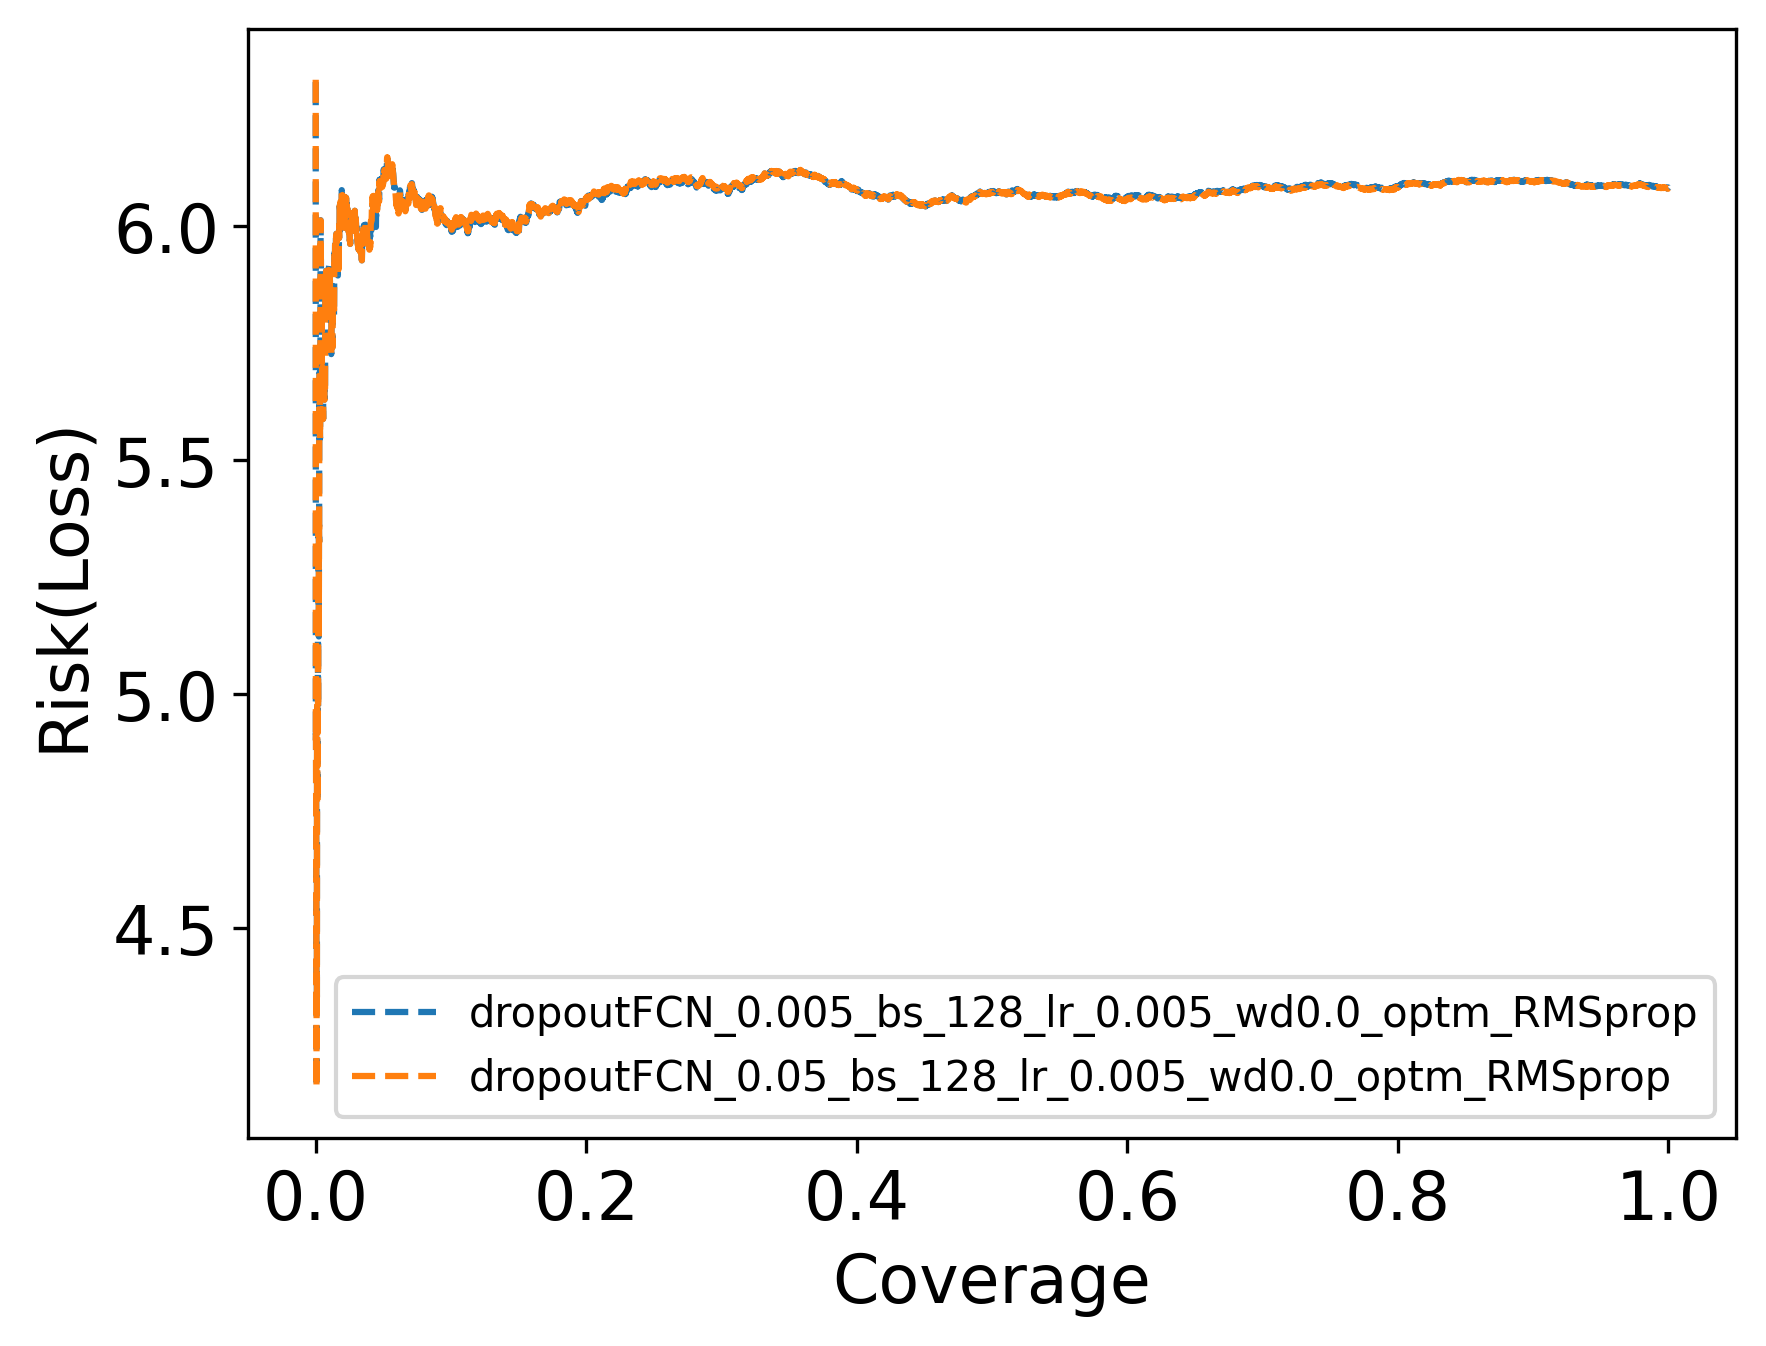

In [10]:
plt.figure(dpi=300)
folders.sort()
for folder in folders:
    if folder[:3] == 'FCN':
        continue
    if 'noisyFCN' in folder:
        model_name = 'noisyFCN'
        init_noiselevel = float(re.search(r'noisyFCN_(.*?)_', folder).group(1))
    elif 'dropoutFCN' in folder:
        model_name = 'dropoutFCN'
        dropout_prob = float(re.search(r'dropoutFCN_(.*?)_', folder).group(1))
    elif 'fixnoiseFCN' in folder:
        model_name = 'fixnoiseFCN'
        fix_noiselevel = float(re.search(r'fixnoiseFCN_(.*?)_', folder).group(1))
    else:
        model_name = 'FCN'
    save_path, first_path = get_first_path()
    loss_list_last = np.load(os.path.join(save_path, 'loss_list_last.npy'))
    loss_list_best = np.load(os.path.join(save_path, 'loss_list_best.npy'))
    total_num = len(loss_list_last)
    epochs = np.arange(total_num)
    # 根据输出方差排序样本后，前n个样本输出均值的平均accuracy
    plt.plot((epochs + 1)/len(epochs), [np.sqrt(loss) for loss in loss_list_best], label=folder, linestyle='--')  # bo:blue dot蓝点
plt.legend()
plt.xlabel('Coverage', fontsize=16)
plt.ylabel('Risk(Loss)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [ ]:
folders

In [ ]:
plt.figure(dpi=300)
folders.sort()
folder = 'noisyFCN_0.05_bs_32_lr_0.005_wd0.0_optm_Adam'
if 'noisyFCN' in folder:
    model_name = 'noisyFCN'
    init_noiselevel = float(re.search(r'noisyFCN_(.*?)_', folder).group(1))
elif 'dropoutFCN' in folder:
    model_name = 'dropoutFCN'
    dropout_prob = float(re.search(r'dropoutFCN_(.*?)_', folder).group(1))
elif 'fixnoiseFCN' in folder:
    model_name = 'fixnoiseFCN'
    fix_noiselevel = float(re.search(r'fixnoiseFCN_(.*?)_', folder).group(1))
else:
    model_name = 'FCN'
save_path, first_path = get_first_path()
loss_list_last = np.load(os.path.join(save_path, 'loss_list_last.npy'))
loss_list_best = np.load(os.path.join(save_path, 'loss_list_best.npy'))

In [ ]:
plt.plot(loss_list_last)

In [ ]:
folders = ['noisyFCN_0.01_bs_32_lr_0.005_wd0.0_optm_Adam']
for folder in folders:
    if folder[:3] == 'FCN':
        continue
    if 'noisyFCN' in folder:
        model_name = 'noisyFCN'
        init_noiselevel = float(re.search(r'noisyFCN_(.*?)_', folder).group(1))
    elif 'dropoutFCN' in folder:
        model_name = 'dropoutFCN'
        dropout_prob = float(re.search(r'dropoutFCN_(.*?)_', folder).group(1))
    elif 'fixnoiseFCN' in folder:
        model_name = 'fixnoiseFCN'
        fix_noiselevel = float(re.search(r'fixnoiseFCN_(.*?)_', folder).group(1))
    else:
        model_name = 'FCN'

    # 直接选第一个fold看结果
    fold = 0
    print('fold {}'.format(fold))
    X_train, y_train, X_val, y_val = load_fold(folds_path, fold, X, y)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32)
    val_data = torch.utils.data.TensorDataset(X_val, y_val)
    val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4)
    last_model = def_model(model_name, input_size, hidden_sizes, output_size)
    best_model = def_model(model_name, input_size, hidden_sizes, output_size)
    criterion = nn.MSELoss()
    if use_cuda:
        last_model.cuda()
        best_model.cuda()
        criterion.cuda()

    save_path, first_path = get_first_path()
    print('first_path: {}'.format(first_path))

    # 只选第一个模型
    last_model_path = os.path.join(first_path, 'checkpoint.pth.tar')
    best_model_path = os.path.join(first_path, 'model_best.pth.tar')
    last_checkpoint = torch.load(last_model_path)
    best_checkpoint = torch.load(best_model_path)

    state_tmp1 = last_model.state_dict()
    if 'state_dict' in last_checkpoint.keys():
        state_tmp1.update(last_checkpoint['state_dict'])
    else:
        state_tmp1.update(last_checkpoint)

    last_model.load_state_dict(state_tmp1)
    print("=> loaded last_model '{}' (epoch {})".format(last_model_path, last_checkpoint['epoch']))

    state_tmp2 = best_model.state_dict()
    if 'state_dict' in best_checkpoint.keys():
        state_tmp2.update(best_checkpoint['state_dict'])
    else:
        state_tmp2.update(best_checkpoint)

    best_model.load_state_dict(state_tmp2)
    print("=> loaded best_model '{}' (epoch {})".format(best_model_path, best_checkpoint['epoch']))

    val_loss_last, var_outputs_all_last, pred_all_last = validate(model=last_model, val_loader=val_loader, criterion=criterion)
    val_loss_best, var_outputs_all_best, pred_all_best = validate(model=best_model, val_loader=val_loader, criterion=criterion)

    sorted_index_last = np.argsort(var_outputs_all_last)
    sorted_index_best = np.argsort(var_outputs_all_best)
    total_num = len(sorted_index_last)
    y_pre_array_last = np.array(pred_all_last)
    y_pre_array_best = np.array(pred_all_best)
    y_test = np.array(val_data.tensors[1])
    sorted_y_pred_last = y_pre_array_last[sorted_index_last]  # 从预测方差从小到大排序
    sorted_y_pred_best = y_pre_array_best[sorted_index_best]  # 从预测方差从小到大排序
    sorted_y_data_last = y_test[sorted_index_last]
    sorted_y_data_best = y_test[sorted_index_best]
    loss_list_last = []
    loss_list_best = []

    for i in range(1, total_num + 1):
        sorted_y_pred1_last = sorted_y_pred_last[0:i]
        sorted_y_pred1_best = sorted_y_pred_best[0:i]
        sorted_y_data1_last = sorted_y_data_last[0:i]
        sorted_y_data1_best = sorted_y_data_best[0:i]
        loss_last = criterion(torch.tensor(sorted_y_pred1_last), torch.tensor(sorted_y_data1_last))
        loss_last = float(loss_last)
        loss_best = criterion(torch.tensor(sorted_y_pred1_best), torch.tensor(sorted_y_data1_best))
        loss_best = float(loss_best)
        loss_list_last.append(loss_last)
        loss_list_best.append(loss_best)

    np.save(os.path.join(save_path, 'loss_list_last.npy'), loss_list_last)
    np.save(os.path.join(save_path, 'loss_list_best.npy'), loss_list_best)

In [ ]:
print([(name, param) for name, param in best_model.named_parameters() if 'alpha' in name])